In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001F8E1DADB90> [0]

In [3]:
REGION = 'Nord'
YEAR = '2014'

In [5]:
timeline_file = pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Timeline_{YEAR}_filled_cleaned.csv', encoding=enc)

In [6]:
try:
    timeline_file.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [7]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-01,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15414.0,NaN,0.0
1,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-02,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15332.0,14452.0,0.0
2,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-03,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15376.0,14391.0,0.0
3,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-04,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15376.0,14440.0,0.0
4,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-05,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15337.0,14433.0,0.0


In [8]:
print(f'Shape of the timeline file: {timeline_file.shape}')

Shape of the timeline file: (1445035, 24)


Text(0.5, 1.0, 'Year: 2014')

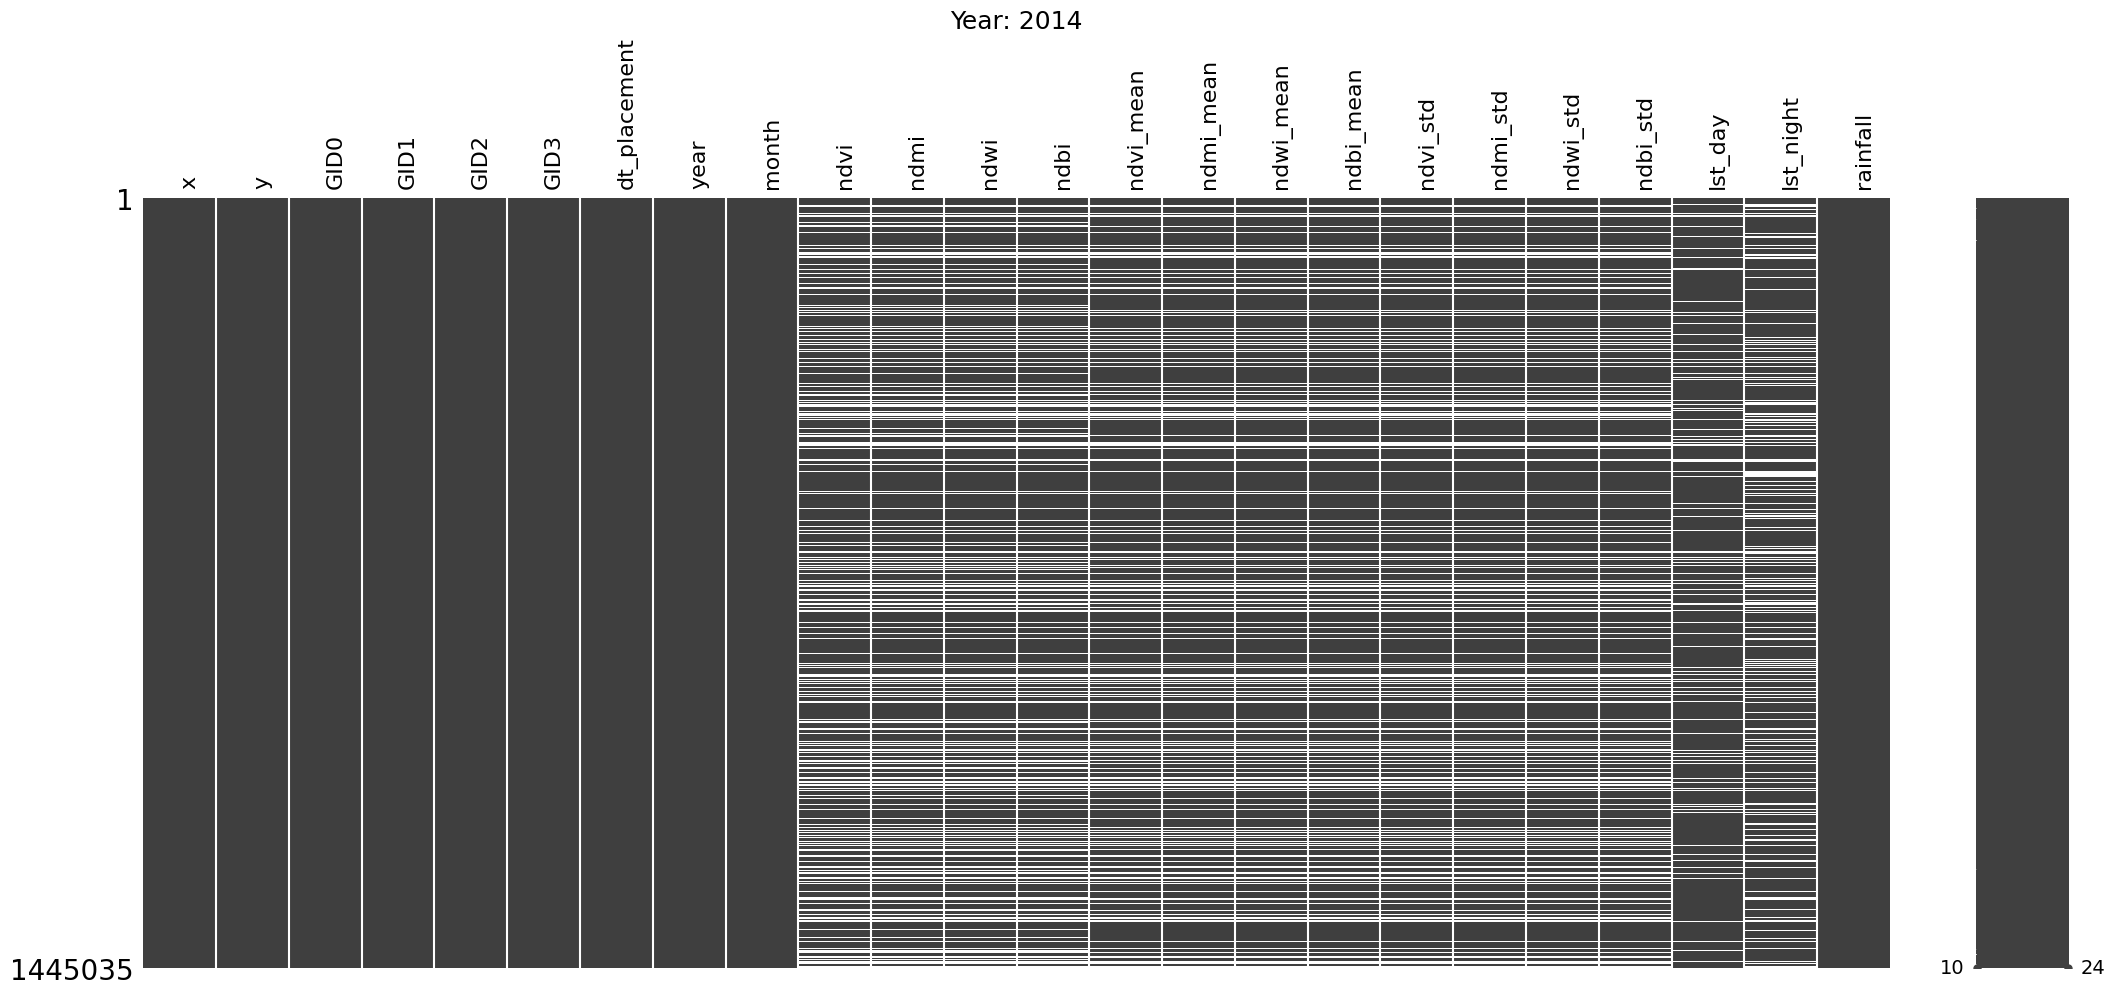

In [9]:
msno.matrix(timeline_file, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {timeline_file.year.iloc[0]}", fontsize=18)

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2

In [11]:
timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [12]:
timeline_file.head()

,x,y,GID0,GID1,GID2,GID3,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-01,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15414.0,NaN,0.0,NaN,0.5,0.866
1,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-02,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15332.0,14452.0,0.0,14892.0,0.5,0.866
2,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-03,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15376.0,14391.0,0.0,14883.5,0.5,0.866
3,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-04,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15376.0,14440.0,0.0,14908.0,0.5,0.866
4,12.29306,8.21972,nord,faro,poli,balkossa,2014-01-05,2014,1,0.188826,-0.134621,-0.347634,0.134621,0.21555,-0.125165,-0.371888,0.125165,0.016083,0.013515,0.018711,0.013515,15337.0,14433.0,0.0,14885.0,0.5,0.866


In [13]:
gid_unit_counts = []

for gid_unit in timeline_file.GID3.sort_values().unique().tolist():
    count = (timeline_file['GID3'] == gid_unit).sum()
    gid_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_unit_counts_df = pd.DataFrame(gid_unit_counts)

In [14]:
fig = px.bar(gid_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [15]:
grouped_by_gid3 = timeline_file.groupby(['dt_placement', 'GID0','GID1','GID2','GID3'], as_index = False)
grouped_by_gid3_mean = grouped_by_gid3.mean()

In [16]:
grouped_by_gid3_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,2014-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014.0,1.0,0.191393,-0.139052,-0.399475,0.139052,0.186486,-0.150932,-0.410917,0.150932,0.012611,0.017759,0.014469,0.017759,15522.800000,NaN,0.000000,NaN,0.5,0.866
1,2014-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014.0,1.0,0.188349,-0.143107,-0.393090,0.143107,0.189412,-0.142039,-0.393650,0.142039,0.012774,0.013065,0.012472,0.013065,15594.564103,NaN,0.000179,NaN,0.5,0.866
2,2014-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014.0,1.0,0.176608,-0.118809,-0.360288,0.118809,0.178185,-0.114829,-0.359463,0.114829,0.012099,0.009560,0.013187,0.009560,15521.000000,14424.0,0.000000,14982.50,0.5,0.866
3,2014-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014.0,1.0,0.208742,-0.104475,-0.365747,0.104475,0.214358,-0.095689,-0.364879,0.095689,0.017369,0.022392,0.020812,0.022392,15416.727273,NaN,0.000000,NaN,0.5,0.866
4,2014-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014.0,1.0,0.179762,-0.041180,-0.288858,0.041180,0.189187,-0.029245,-0.292290,0.029245,0.032395,0.031376,0.067567,0.031376,15354.000000,14585.5,0.000000,14964.25,0.5,0.866


In [17]:
print(f'Shape of the grouped_by_gid3_mean file: {grouped_by_gid3_mean.shape}')

Shape of the grouped_by_gid3_mean file: (52925, 27)


Text(0.5, 1.0, 'Year: 2014.0')

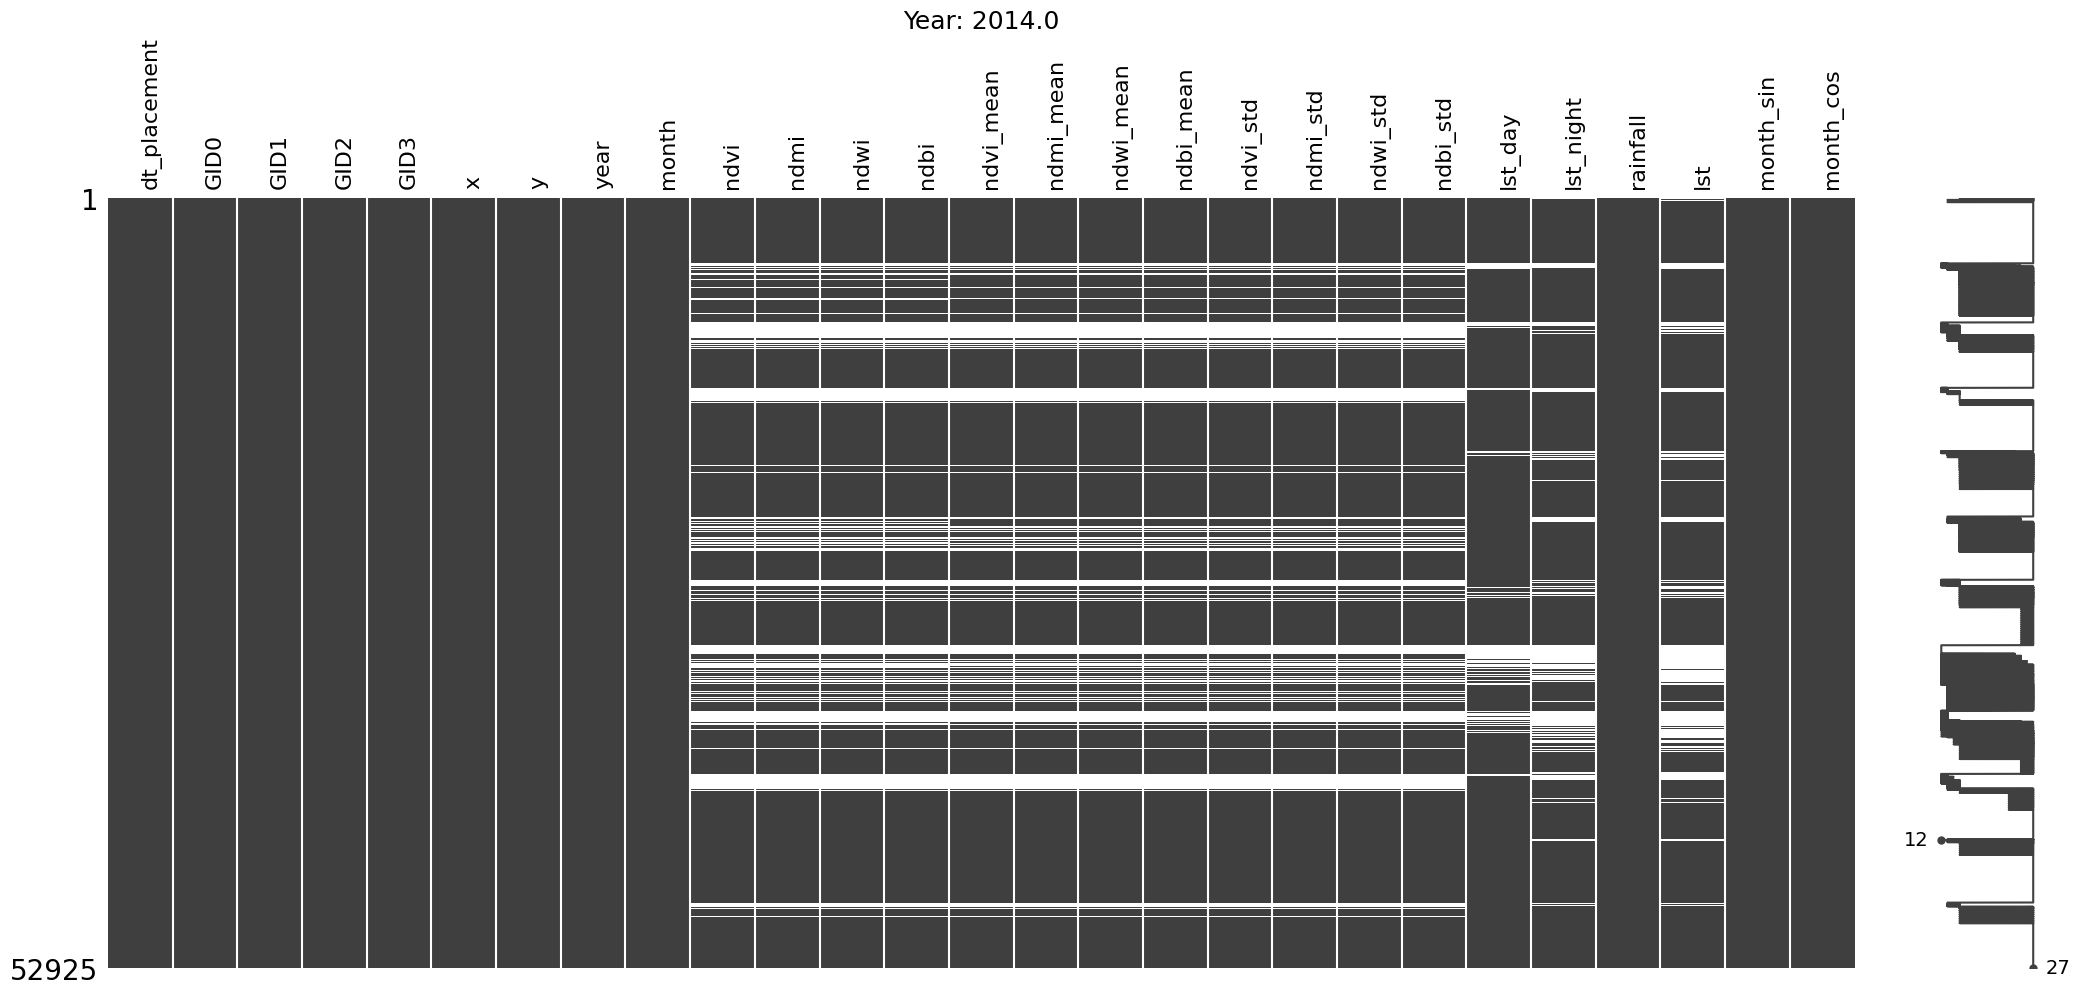

In [18]:
msno.matrix(grouped_by_gid3_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3_mean.year.iloc[0]}", fontsize=18)

In [19]:
gid_mean_unit_counts = []

for gid_unit in grouped_by_gid3_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_gid3_mean['GID3'] == gid_unit).sum()
    gid_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

gid_mean_unit_counts_df = pd.DataFrame(gid_mean_unit_counts)

In [20]:
fig = px.bar(gid_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [21]:
grouped_by_gid3_mean[grouped_by_gid3_mean['GID3'] == 'lam']

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
6,2014-01-01,nord,benoue,bibemi,lam,13.911121,9.543728,2014.0,1.0,0.181854,-0.100547,-0.348587,0.100547,0.185744,-0.095853,-0.346416,0.095853,0.016568,0.014605,0.020231,0.014605,15532.230769,14541.142857,0.0,15022.571429,0.5,0.866
84,2014-01-01,nord,mayo-louti,figuil,lam,14.149831,10.036923,2014.0,1.0,0.186689,-0.108251,-0.377763,0.108251,0.173457,-0.116813,-0.374802,0.116813,0.008989,0.007800,0.007413,0.007800,15437.714286,14554.000000,0.0,14985.000000,0.5,0.866
151,2014-01-02,nord,benoue,bibemi,lam,13.911121,9.543728,2014.0,1.0,0.257142,-0.077147,-0.403277,0.077147,0.259201,-0.073915,-0.402396,0.073915,0.021682,0.019883,0.020447,0.019883,15532.230769,14620.750000,0.0,15063.125000,0.5,0.866
229,2014-01-02,nord,mayo-louti,figuil,lam,14.149831,10.036923,2014.0,1.0,0.267428,-0.079102,-0.430083,0.079102,0.262925,-0.082824,-0.427440,0.082824,0.020268,0.015302,0.012192,0.015302,15437.714286,14613.000000,0.0,15025.357143,0.5,0.866
296,2014-01-03,nord,benoue,bibemi,lam,13.911121,9.543728,2014.0,1.0,0.257142,-0.077147,-0.403277,0.077147,0.259201,-0.073915,-0.402396,0.073915,0.021682,0.019883,0.020447,0.019883,15500.615385,14626.000000,0.0,15063.307692,0.5,0.866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52574,2014-12-29,nord,mayo-louti,figuil,lam,14.149831,10.036923,2014.0,12.0,0.194886,-0.154402,-0.421026,0.154402,0.189035,-0.160862,-0.423240,0.160862,0.012533,0.009567,0.009568,0.009567,15404.428571,14602.000000,0.0,15003.214286,0.0,1.000
52641,2014-12-30,nord,benoue,bibemi,lam,13.911121,9.543728,2014.0,12.0,0.193020,-0.126570,-0.387507,0.126570,0.197253,-0.121135,-0.382812,0.121135,0.018327,0.018427,0.023311,0.018427,15531.076923,14640.846154,0.0,15085.961538,0.0,1.000
52719,2014-12-30,nord,mayo-louti,figuil,lam,14.149831,10.036923,2014.0,12.0,0.194886,-0.154402,-0.421026,0.154402,0.189035,-0.160862,-0.423240,0.160862,0.012533,0.009567,0.009568,0.009567,15543.428571,14602.000000,0.0,15072.714286,0.0,1.000
52786,2014-12-31,nord,benoue,bibemi,lam,13.911121,9.543728,2014.0,12.0,0.193020,-0.126570,-0.387507,0.126570,0.197253,-0.121135,-0.382812,0.121135,0.018327,0.018427,0.023311,0.018427,15594.307692,14697.769231,0.0,15146.038462,0.0,1.000


In [22]:
grouped_by_gid3_mean = convert_temperature(grouped_by_gid3_mean)

In [23]:
grouped_by_gid3_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,2014-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014.0,1.0,0.191393,-0.139052,-0.399475,0.139052,0.186486,-0.150932,-0.410917,0.150932,0.012611,0.017759,0.014469,0.017759,37.306000,NaN,0.000000,NaN,0.5,0.866
1,2014-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014.0,1.0,0.188349,-0.143107,-0.393090,0.143107,0.189412,-0.142039,-0.393650,0.142039,0.012774,0.013065,0.012472,0.013065,38.741282,NaN,0.000179,NaN,0.5,0.866
2,2014-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014.0,1.0,0.176608,-0.118809,-0.360288,0.118809,0.178185,-0.114829,-0.359463,0.114829,0.012099,0.009560,0.013187,0.009560,37.270000,15.33,0.000000,26.300,0.5,0.866
3,2014-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014.0,1.0,0.208742,-0.104475,-0.365747,0.104475,0.214358,-0.095689,-0.364879,0.095689,0.017369,0.022392,0.020812,0.022392,35.184545,NaN,0.000000,NaN,0.5,0.866
4,2014-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014.0,1.0,0.179762,-0.041180,-0.288858,0.041180,0.189187,-0.029245,-0.292290,0.029245,0.032395,0.031376,0.067567,0.031376,33.930000,18.56,0.000000,26.245,0.5,0.866


In [24]:
grouped_by_gid3_mean['year'] = grouped_by_gid3_mean['year'].astype(int)
grouped_by_gid3_mean['month'] = grouped_by_gid3_mean['month'].astype(int)

In [25]:
grouped_by_gid3_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos
0,2014-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014,1,0.191393,-0.139052,-0.399475,0.139052,0.186486,-0.150932,-0.410917,0.150932,0.012611,0.017759,0.014469,0.017759,37.306000,NaN,0.000000,NaN,0.5,0.866
1,2014-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014,1,0.188349,-0.143107,-0.393090,0.143107,0.189412,-0.142039,-0.393650,0.142039,0.012774,0.013065,0.012472,0.013065,38.741282,NaN,0.000179,NaN,0.5,0.866
2,2014-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014,1,0.176608,-0.118809,-0.360288,0.118809,0.178185,-0.114829,-0.359463,0.114829,0.012099,0.009560,0.013187,0.009560,37.270000,15.33,0.000000,26.300,0.5,0.866
3,2014-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014,1,0.208742,-0.104475,-0.365747,0.104475,0.214358,-0.095689,-0.364879,0.095689,0.017369,0.022392,0.020812,0.022392,35.184545,NaN,0.000000,NaN,0.5,0.866
4,2014-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014,1,0.179762,-0.041180,-0.288858,0.041180,0.189187,-0.029245,-0.292290,0.029245,0.032395,0.031376,0.067567,0.031376,33.930000,18.56,0.000000,26.245,0.5,0.866


Text(0.5, 1.0, 'Year: 2014')

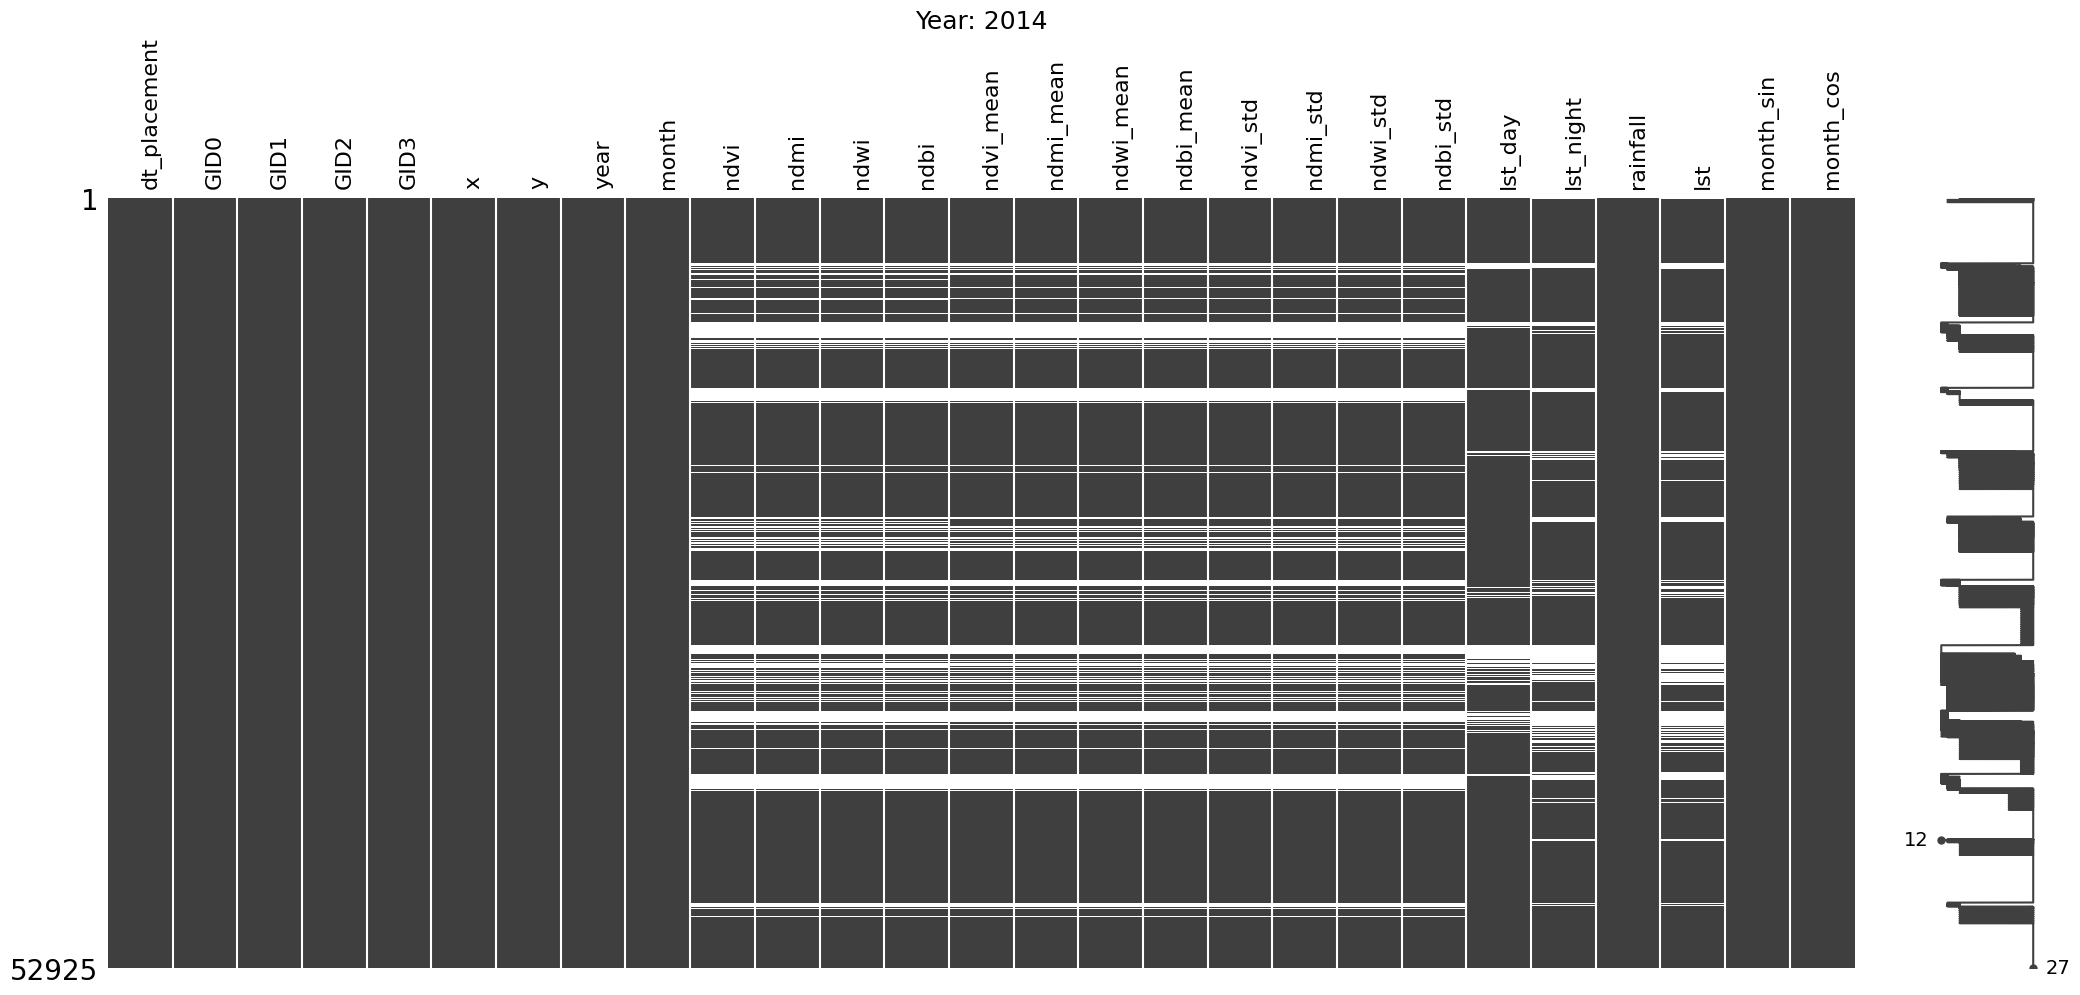

In [26]:
msno.matrix(grouped_by_gid3_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_gid3_mean.year.iloc[0]}", fontsize=18)

In [27]:
# Group by the needed dimensions
grouped_mask = grouped_by_gid3_mean.groupby(['GID2', 'GID3', 'year', 'month'])

# Compute the min and max temperature across lst_day and lst_night
monthly_lst_min = grouped_mask[['lst_day', 'lst_night']].min().min(axis=1)
monthly_lst_max = grouped_mask[['lst_day', 'lst_night']].max().max(axis=1)

# Compute total precipitation
monthly_rainfall_acc = grouped_mask['rainfall'].sum()

# Combine results into a single DataFrame
min_max_acc_weather_df = pd.DataFrame({
    'monthly_lst_min': monthly_lst_min,
    'monthly_lst_max': monthly_lst_max,
    'monthly_rainfall_acc': monthly_rainfall_acc
}).reset_index()

In [28]:
min_max_acc_weather_df

,GID2,GID3,year,month,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,bibemi,adoumri,2014,1,15.322000,44.602000,0.146000
1,bibemi,adoumri,2014,2,16.290000,46.402000,1.655400
2,bibemi,adoumri,2014,3,16.974000,51.258000,42.442600
3,bibemi,adoumri,2014,4,17.930000,49.822000,59.711198
4,bibemi,adoumri,2014,5,22.790000,45.406000,139.863597
...,...,...,...,...,...,...,...
1735,touboro,yanli,2014,8,19.490000,28.640000,585.928374
1736,touboro,yanli,2014,9,19.140000,31.133871,461.365538
1737,touboro,yanli,2014,10,19.986774,32.120323,200.644672
1738,touboro,yanli,2014,11,16.233226,36.278387,1.646742


In [29]:
dataset = pd.merge(grouped_by_gid3_mean, min_max_acc_weather_df, on=['GID2', 'GID3', 'year', 'month'], how='left')

In [30]:
dataset.head()


,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2014-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014,1,0.191393,-0.139052,-0.399475,0.139052,0.186486,-0.150932,-0.410917,0.150932,0.012611,0.017759,0.014469,0.017759,37.306000,NaN,0.000000,NaN,0.5,0.866,15.322000,44.602000,0.146000
1,2014-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014,1,0.188349,-0.143107,-0.393090,0.143107,0.189412,-0.142039,-0.393650,0.142039,0.012774,0.013065,0.012472,0.013065,38.741282,NaN,0.000179,NaN,0.5,0.866,16.512051,44.394615,0.266077
2,2014-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014,1,0.176608,-0.118809,-0.360288,0.118809,0.178185,-0.114829,-0.359463,0.114829,0.012099,0.009560,0.013187,0.009560,37.270000,15.33,0.000000,26.300,0.5,0.866,15.330000,45.234000,0.143333
3,2014-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014,1,0.208742,-0.104475,-0.365747,0.104475,0.214358,-0.095689,-0.364879,0.095689,0.017369,0.022392,0.020812,0.022392,35.184545,NaN,0.000000,NaN,0.5,0.866,14.750000,42.673636,0.129091
4,2014-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014,1,0.179762,-0.041180,-0.288858,0.041180,0.189187,-0.029245,-0.292290,0.029245,0.032395,0.031376,0.067567,0.031376,33.930000,18.56,0.000000,26.245,0.5,0.866,16.943333,43.350000,0.000000


Text(0.5, 1.0, 'Year: 2014')

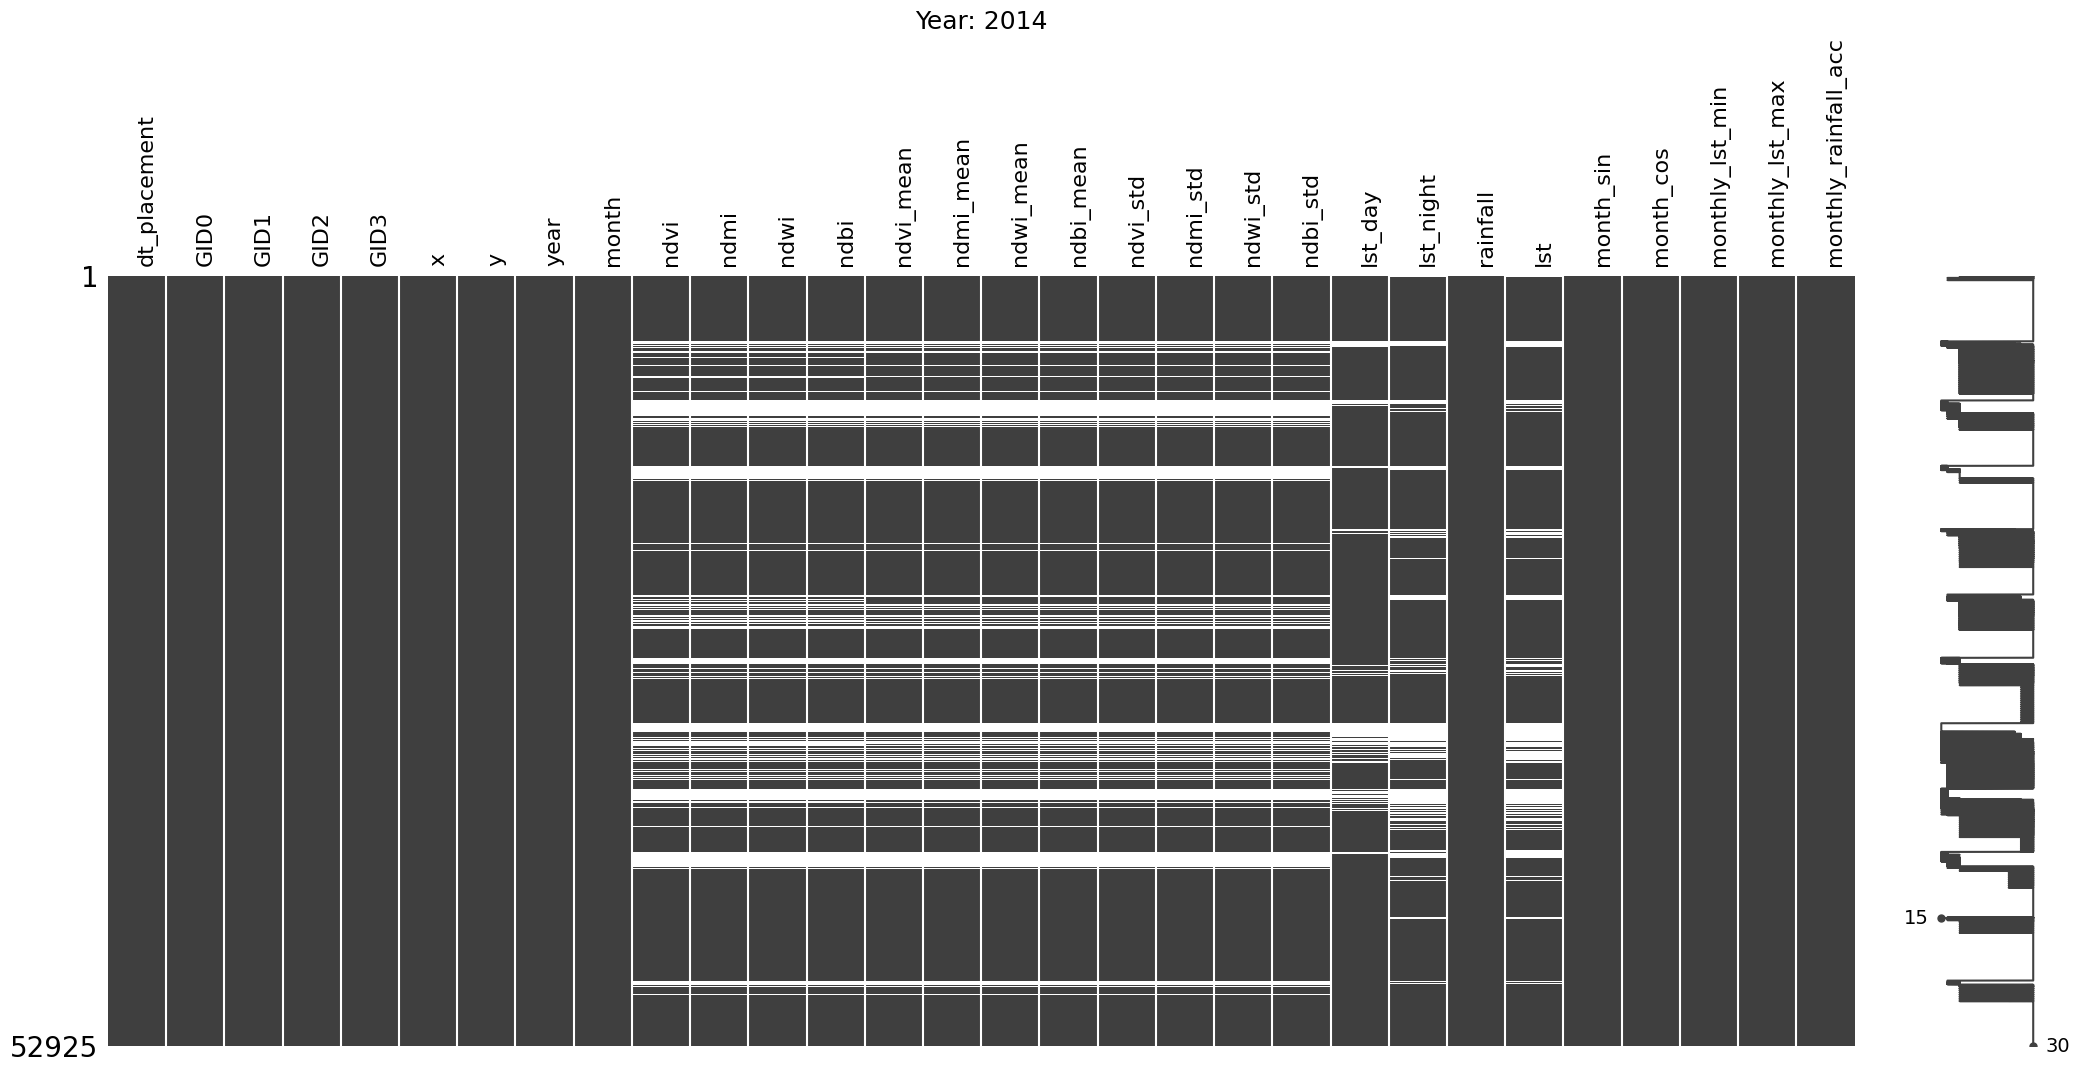

In [31]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [32]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [33]:
dataset.head()

,dt_placement_daily,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,dt_placement
0,2014-01-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014,1,0.191393,-0.139052,-0.399475,0.139052,0.186486,-0.150932,-0.410917,0.150932,0.012611,0.017759,0.014469,0.017759,37.306000,NaN,0.000000,NaN,0.5,0.866,15.322000,44.602000,0.146000,2014-01
1,2014-01-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014,1,0.188349,-0.143107,-0.393090,0.143107,0.189412,-0.142039,-0.393650,0.142039,0.012774,0.013065,0.012472,0.013065,38.741282,NaN,0.000179,NaN,0.5,0.866,16.512051,44.394615,0.266077,2014-01
2,2014-01-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014,1,0.176608,-0.118809,-0.360288,0.118809,0.178185,-0.114829,-0.359463,0.114829,0.012099,0.009560,0.013187,0.009560,37.270000,15.33,0.000000,26.300,0.5,0.866,15.330000,45.234000,0.143333,2014-01
3,2014-01-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014,1,0.208742,-0.104475,-0.365747,0.104475,0.214358,-0.095689,-0.364879,0.095689,0.017369,0.022392,0.020812,0.022392,35.184545,NaN,0.000000,NaN,0.5,0.866,14.750000,42.673636,0.129091,2014-01
4,2014-01-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014,1,0.179762,-0.041180,-0.288858,0.041180,0.189187,-0.029245,-0.292290,0.029245,0.032395,0.031376,0.067567,0.031376,33.930000,18.56,0.000000,26.245,0.5,0.866,16.943333,43.350000,0.000000,2014-01


In [34]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement','GID0','GID1','GID2','GID3'], as_index = False)

In [35]:
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_sum = grouped_by_month.sum()

In [36]:
grouped_by_month_mean.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2014-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014.0,1.0,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,39.142645,17.131000,0.004710,28.167433,0.5,0.866,15.322000,44.602000,0.146000
1,2014-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014.0,1.0,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,39.037560,18.530094,0.008583,28.788765,0.5,0.866,16.512051,44.394615,0.266077
2,2014-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014.0,1.0,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,38.961484,18.343247,0.004624,28.652366,0.5,0.866,15.330000,45.234000,0.143333
3,2014-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014.0,1.0,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,37.705484,16.466121,0.004164,27.127818,0.5,0.866,14.750000,42.673636,0.129091
4,2014-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014.0,1.0,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,37.271075,19.350108,0.000000,28.310591,0.5,0.866,16.943333,43.350000,0.000000


In [37]:
print(f'Shape of the grouped_by_month_mean file: {grouped_by_month_mean.shape}')

Shape of the grouped_by_month_mean file: (1740, 30)


Text(0.5, 1.0, 'Year: 2014.0')

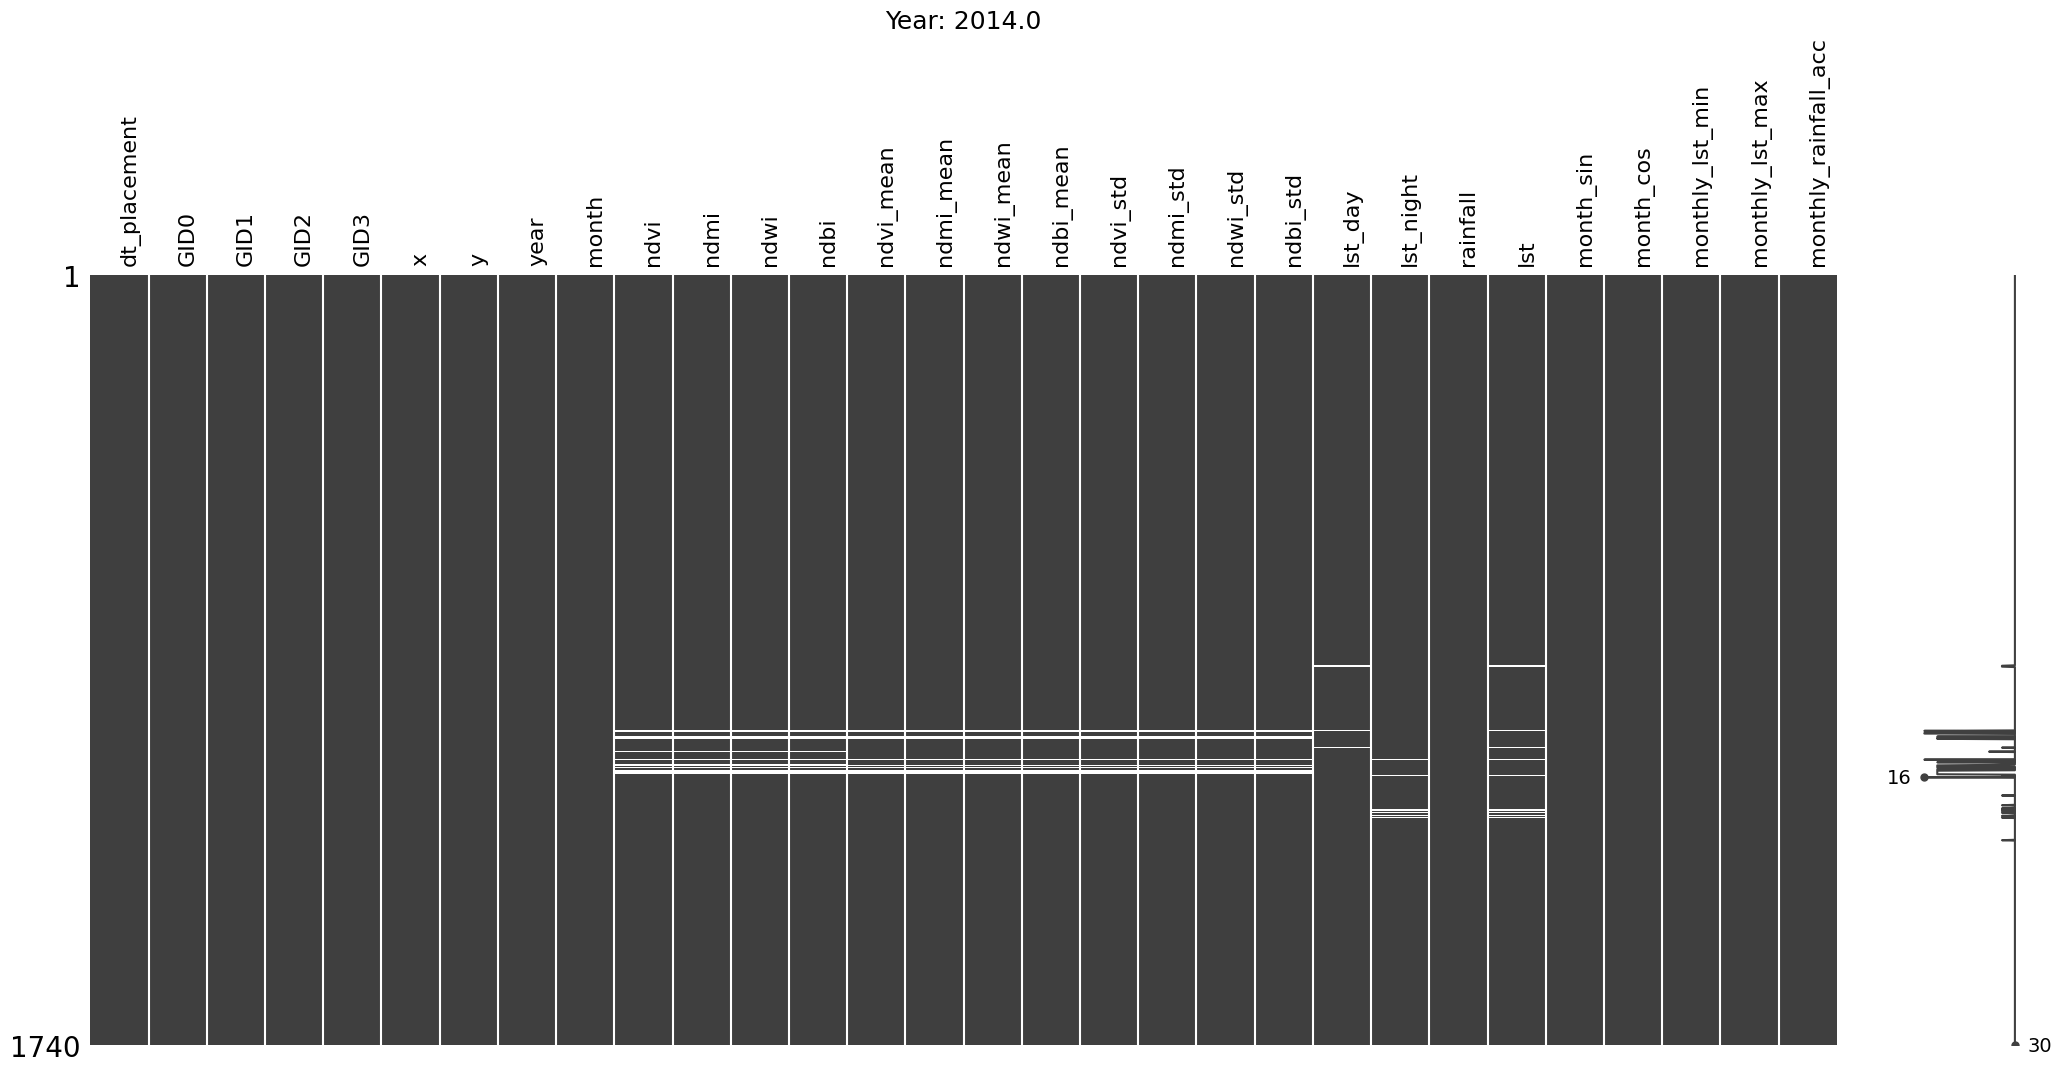

In [38]:
msno.matrix(grouped_by_month_mean, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {grouped_by_month_mean.year.iloc[0]}", fontsize=18)

In [39]:
month_mean_unit_counts = []

for gid_unit in grouped_by_month_mean.GID3.sort_values().unique().tolist():
    count = (grouped_by_month_mean['GID3'] == gid_unit).sum()
    month_mean_unit_counts.append({'GID3': gid_unit,
                            'count': count})

month_mean_unit_counts_df = pd.DataFrame(month_mean_unit_counts)

In [40]:
fig = px.bar(month_mean_unit_counts_df, x='GID3', y='count', title='Count per Region')
fig.update_layout(xaxis_title='Region (GID3)', yaxis_title='Count')
fig.show()

In [41]:
grouped_by_month_mean['year'] = grouped_by_month_mean['year'].astype(int)
grouped_by_month_mean['month'] = grouped_by_month_mean['month'].astype(int)

In [42]:
grouped_by_month_mean

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc
0,2014-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014,1,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,39.142645,17.131000,0.004710,28.167433,0.5,0.866,15.322000,44.602000,0.146000
1,2014-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014,1,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,39.037560,18.530094,0.008583,28.788765,0.5,0.866,16.512051,44.394615,0.266077
2,2014-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014,1,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,38.961484,18.343247,0.004624,28.652366,0.5,0.866,15.330000,45.234000,0.143333
3,2014-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014,1,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,37.705484,16.466121,0.004164,27.127818,0.5,0.866,14.750000,42.673636,0.129091
4,2014-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014,1,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,37.271075,19.350108,0.000000,28.310591,0.5,0.866,16.943333,43.350000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2014-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2014,12,0.361220,-0.003694,-0.346105,0.003694,0.361267,-0.003751,-0.345794,0.003751,0.020735,0.022422,0.022489,0.022422,30.739611,16.051698,0.004133,23.395655,0.0,1.000,14.665214,33.534103,0.128120
1736,2014-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2014,12,0.328045,-0.055945,-0.395070,0.055945,0.330209,-0.052644,-0.393478,0.052644,0.017486,0.021012,0.020719,0.021012,32.951780,17.708458,0.003843,25.330119,0.0,1.000,16.127931,36.654138,0.119138
1737,2014-12,nord,mayo-rey,touboro,touboro,15.293957,7.759324,2014,12,0.343187,-0.025485,-0.362275,0.025485,0.341019,-0.028293,-0.364350,0.028293,0.016973,0.023168,0.020056,0.023168,31.991121,16.500638,0.003930,24.245879,0.0,1.000,14.985000,35.830500,0.121825
1738,2014-12,nord,mayo-rey,touboro,vogzom,14.714359,7.747549,2014,12,0.354285,-0.034846,-0.382024,0.034846,0.351825,-0.036138,-0.381193,0.036138,0.022874,0.021763,0.023319,0.021763,32.574498,15.876711,0.002090,24.204941,0.0,1.000,14.602150,35.712804,0.064794


In [43]:
grouped_by_month_sum = grouped_by_month_sum[['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3', 'rainfall']].copy()
grouped_by_month_sum.rename(columns={"rainfall": "rainfall_acc"}, inplace=True)

dataset = pd.merge(grouped_by_month_mean, grouped_by_month_sum, on=['dt_placement', 'GID0', 'GID1', 'GID2', 'GID3'], how='left')

In [44]:
dataset.head()

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc
0,2014-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014,1,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,39.142645,17.131000,0.004710,28.167433,0.5,0.866,15.322000,44.602000,0.146000,0.146000
1,2014-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014,1,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,39.037560,18.530094,0.008583,28.788765,0.5,0.866,16.512051,44.394615,0.266077,0.266077
2,2014-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014,1,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,38.961484,18.343247,0.004624,28.652366,0.5,0.866,15.330000,45.234000,0.143333,0.143333
3,2014-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014,1,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,37.705484,16.466121,0.004164,27.127818,0.5,0.866,14.750000,42.673636,0.129091,0.129091
4,2014-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014,1,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,37.271075,19.350108,0.000000,28.310591,0.5,0.866,16.943333,43.350000,0.000000,0.000000


In [45]:
dataset['location'] = list(zip(dataset['GID2'], dataset['GID3']))
grouped = dataset.groupby(['year', 'location'])
bio_var_names = [f'bio{i}' for i in range(1, 20)]

# Store results
biovars = []

# Iterate over groups
for (year, location), group in grouped:
    tmin = robjects.IntVector(group['monthly_lst_min'].tolist())
    tmax = robjects.IntVector(group['monthly_lst_max'].tolist())
    prec = robjects.IntVector(group['monthly_rainfall_acc'].tolist())

    # Call the R function
    bio_values = list(dismo.biovars(prec, tmin, tmax))

    # Construct the result dict dynamically
    result = {
        'year': year,
        'location': location,
        **dict(zip(bio_var_names, bio_values))
    }
    biovars.append(result)

# Convert to DataFrame
biovars_df = pd.DataFrame(biovars)

In [46]:
dataset = pd.merge(dataset, biovars_df,  how='left', on=['location', 'year'])

dataset.drop(columns=['location'], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [47]:
dataset

,dt_placement,GID0,GID1,GID2,GID3,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,lst,month_sin,month_cos,monthly_lst_min,monthly_lst_max,monthly_rainfall_acc,rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2014-01,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014,1,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,39.142645,17.131000,0.004710,28.167433,0.5,0.866,15.322000,44.602000,0.146000,0.146000,29.500000,22.500000,60.810811,276.339712,51.0,14.0,37.0,26.333333,28.833333,33.333333,26.333333,1968.0,537.0,0.0,114.714846,1294.0,1.0,240.0,1294.0
1,2014-01,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014,1,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,39.037560,18.530094,0.008583,28.788765,0.5,0.866,16.512051,44.394615,0.266077,0.266077,29.333333,20.500000,60.294118,349.241603,50.0,16.0,34.0,25.833333,29.166667,34.333333,25.666667,2013.0,583.0,0.0,120.039566,1353.0,2.0,94.0,1275.0
2,2014-01,nord,benoue,bibemi,bide,13.972945,9.422292,2014,1,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,38.961484,18.343247,0.004624,28.652366,0.5,0.866,15.330000,45.234000,0.143333,0.143333,30.083333,21.166667,58.796296,308.097781,51.0,15.0,36.0,27.500000,30.333333,34.500000,26.833333,1845.0,540.0,0.0,120.788415,1240.0,0.0,81.0,1178.0
3,2014-01,nord,benoue,bibemi,dengui,13.642496,9.235656,2014,1,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,37.705484,16.466121,0.004164,27.127818,0.5,0.866,14.750000,42.673636,0.129091,0.129091,29.166667,22.000000,61.111111,310.668878,49.0,13.0,36.0,25.833333,28.000000,33.666667,25.833333,2049.0,539.0,0.0,112.590079,1314.0,1.0,243.0,1314.0
4,2014-01,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014,1,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,37.271075,19.350108,0.000000,28.310591,0.5,0.866,16.943333,43.350000,0.000000,0.000000,30.250000,20.166667,56.018519,284.045451,51.0,15.0,36.0,28.000000,29.000000,34.000000,28.000000,1872.0,521.0,0.0,119.390807,1228.0,0.0,98.0,997.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1735,2014-12,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2014,12,0.361220,-0.003694,-0.346105,0.003694,0.361267,-0.003751,-0.345794,0.003751,0.020735,0.022422,0.022489,0.022422,30.739611,16.051698,0.004133,23.395655,0.0,1.000,14.665214,33.534103,0.128120,0.128120,25.666667,17.166667,53.645833,345.972498,46.0,14.0,32.0,22.500000,26.000000,30.500000,22.500000,2485.0,672.0,0.0,113.691866,1662.0,0.0,122.0,1662.0
1736,2014-12,nord,mayo-rey,touboro,ngai-lara,15.110765,7.963850,2014,12,0.328045,-0.055945,-0.395070,0.055945,0.330209,-0.052644,-0.393478,0.052644,0.017486,0.021012,0.020719,0.021012,32.951780,17.708458,0.003843,25.330119,0.0,1.000,16.127931,36.654138,0.119138,0.119138,27.083333,18.666667,50.450450,410.561330,49.0,12.0,37.0,22.833333,27.833333,32.500000,22.833333,2402.0,634.0,0.0,112.544804,1570.0,2.0,75.0,1570.0
1737,2014-12,nord,mayo-rey,touboro,touboro,15.293957,7.759324,2014,12,0.343187,-0.025485,-0.362275,0.025485,0.341019,-0.028293,-0.364350,0.028293,0.016973,0.023168,0.020056,0.023168,31.991121,16.500638,0.003930,24.245879,0.0,1.000,14.985000,35.830500,0.121825,0.121825,27.458333,19.583333,52.927928,410.907163,50.0,13.0,37.0,23.666667,27.666667,33.000000,23.500000,2390.0,628.0,0.0,114.241589,1585.0,0.0,241.0,1428.0
1738,2014-12,nord,mayo-rey,touboro,vogzom,14.714359,7.747549,2014,12,0.354285,-0.034846,-0.382024,0.034846,0.351825,-0.036138,-0.381193,

Text(0.5, 1.0, 'Year: 2014')

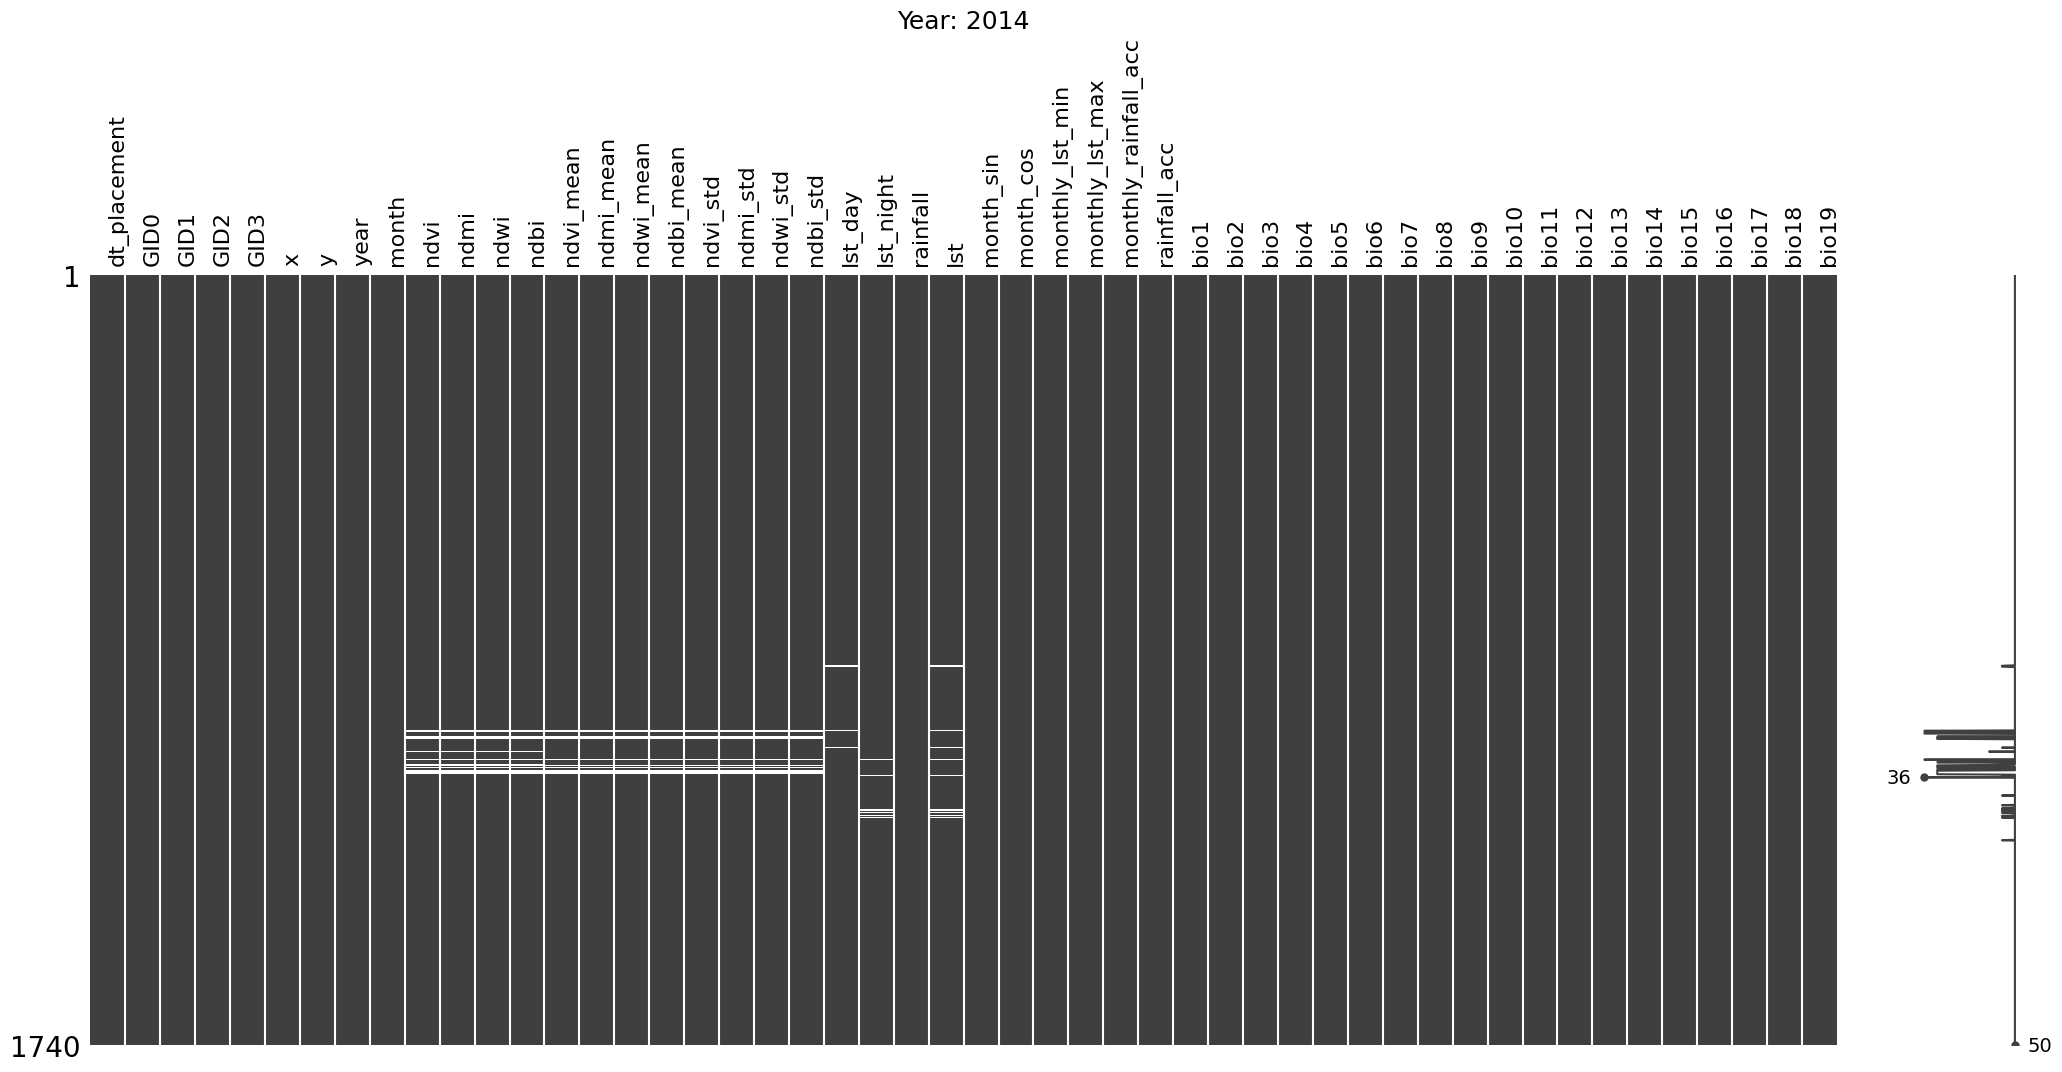

In [48]:
msno.matrix(dataset, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Year: {dataset.year.iloc[0]}", fontsize=18)

In [49]:
dataset[dataset.select_dtypes(include='float').columns] = dataset.select_dtypes(include='float').round(6)

rainfall_cols = [col for col in dataset.columns if 'rainfall' in col]
dataset[rainfall_cols] = dataset[rainfall_cols].round(4)

lst_cols = [col for col in dataset.columns if 'lst' in col]
dataset[lst_cols] = dataset[lst_cols].round(2)

bio_cols = [col for col in dataset.columns if 'bio' in col]
dataset[bio_cols] = dataset[bio_cols].round(2)


In [50]:
new_order = ['dt_placement',
             'year',
             'month',
             'month_sin',
             'month_cos',
             'GID0',
             'GID1',
             'GID2',
             'GID3',
             'x',
             'y',
             'ndvi',
             'ndmi',
             'ndwi',
             'ndbi',
             'ndvi_mean',
             'ndmi_mean',
             'ndwi_mean',
             'ndbi_mean',
             'ndvi_std',
             'ndmi_std',
             'ndwi_std',
             'ndbi_std',
             'lst',
             'lst_day',
             'lst_night',
             'monthly_lst_min',
             'monthly_lst_max',
             'rainfall',
             'rainfall_acc',
             'monthly_rainfall_acc',
             'bio1',
             'bio2',
             'bio3',
             'bio4',
             'bio5',
             'bio6',
             'bio7',
             'bio8',
             'bio9',
             'bio10',
             'bio11',
             'bio12',
             'bio13',
             'bio14',
             'bio15',
             'bio16',
             'bio17',
             'bio18',
             'bio19']

In [51]:
dataset = dataset[new_order]

In [52]:
dataset.head()

,dt_placement,year,month,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,rainfall,rainfall_acc,monthly_rainfall_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,2014-01,2014,1,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,28.17,39.14,17.13,15.32,44.60,0.0047,0.1460,0.1460,29.50,22.50,60.81,276.34,51.0,14.0,37.0,26.33,28.83,33.33,26.33,1968.0,537.0,0.0,114.71,1294.0,1.0,240.0,1294.0
1,2014-01,2014,1,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,28.79,39.04,18.53,16.51,44.39,0.0086,0.2661,0.2661,29.33,20.50,60.29,349.24,50.0,16.0,34.0,25.83,29.17,34.33,25.67,2013.0,583.0,0.0,120.04,1353.0,2.0,94.0,1275.0
2,2014-01,2014,1,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,28.65,38.96,18.34,15.33,45.23,0.0046,0.1433,0.1433,30.08,21.17,58.80,308.10,51.0,15.0,36.0,27.50,30.33,34.50,26.83,1845.0,540.0,0.0,120.79,1240.0,0.0,81.0,1178.0
3,2014-01,2014,1,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,27.13,37.71,16.47,14.75,42.67,0.0042,0.1291,0.1291,29.17,22.00,61.11,310.67,49.0,13.0,36.0,25.83,28.00,33.67,25.83,2049.0,539.0,0.0,112.59,1314.0,1.0,243.0,1314.0
4,2014-01,2014,1,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,28.31,37.27,19.35,16.94,43.35,0.0000,0.0000,0.0000,30.25,20.17,56.02,284.05,51.0,15.0,36.0,28.00,29.00,34.00,28.00,1872.0,521.0,0.0,119.39,1228.0,0.0,98.0,997.0


In [53]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype    
---  ------                --------------  -----    
 0   dt_placement          1740 non-null   period[M]
 1   year                  1740 non-null   int32    
 2   month                 1740 non-null   int32    
 3   month_sin             1740 non-null   float64  
 4   month_cos             1740 non-null   float64  
 5   GID0                  1740 non-null   object   
 6   GID1                  1740 non-null   object   
 7   GID2                  1740 non-null   object   
 8   GID3                  1740 non-null   object   
 9   x                     1740 non-null   float64  
 10  y                     1740 non-null   float64  
 11  ndvi                  1713 non-null   float64  
 12  ndmi                  1713 non-null   float64  
 13  ndwi                  1713 non-null   float64  
 14  ndbi                  1713 non-null   fl

In [54]:
dataset.to_csv(f'../../data/ExtNord/CM_{REGION}_Timeline_{YEAR}_grouped.csv', index=False, encoding=enc)